<a href="https://colab.research.google.com/github/aswinrj401-del/AI-DEEP-VISION/blob/main/Day3_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!unzip /content/catdog.zip -d /content/catdog

Archive:  /content/catdog.zip
replace /content/catdog/catdog/cat1.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
image_folder = "/content/catdog/catdog"# while zipping,one more folder called dogcat was again created, there for two dogcat

images = []  # This list will store the image data.
labels = []  # This list stores the class of each image. (cat=0, dog=1)

for filename in os.listdir(image_folder):

    if filename.endswith((".jpg", ".png", ".jpeg")):

        img_path = os.path.join(image_folder, filename)  # Complete path

        img = cv2.imread(img_path)      # Read the image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))

        images.append(img)  # Store the processed image

        # Label creation
        if filename.startswith("c"):
            labels.append(0)      # Cat
            print(filename, "-> Label: 0 (Cat)")

        elif filename.startswith("d"):
            labels.append(1)      # Dog
            print(filename, "-> Label: 1 (Dog)")

print("\nAll Labels:", labels)

cat8.jpeg -> Label: 0 (Cat)
cat9.jpeg -> Label: 0 (Cat)
cat10.jpeg -> Label: 0 (Cat)
cat2.jpeg -> Label: 0 (Cat)
dog9.jpeg -> Label: 1 (Dog)
dog5.jpeg -> Label: 1 (Dog)
cat4.jpeg -> Label: 0 (Cat)
cat7.jpeg -> Label: 0 (Cat)
dog7.jpeg -> Label: 1 (Dog)
dog1.jpeg -> Label: 1 (Dog)
dog8.jpeg -> Label: 1 (Dog)
dog10.jpeg -> Label: 1 (Dog)
dog2.jpeg -> Label: 1 (Dog)
cat6.jpeg -> Label: 0 (Cat)
cat5.jpeg -> Label: 0 (Cat)
dog4.jpeg -> Label: 1 (Dog)
cat3.jpeg -> Label: 0 (Cat)
dog3.jpeg -> Label: 1 (Dog)
dog6.jpeg -> Label: 1 (Dog)
cat1.jpeg -> Label: 0 (Cat)

All Labels: [0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0]


In [11]:
print("Total Images:", len(images))
print("Total Labels:", len(labels))

Total Images: 20
Total Labels: 20


In [12]:
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y)

(20, 224, 224, 3)
[0 0 0 0 1 1 0 0 1 1 1 1 1 0 0 1 0 1 1 0]


In [13]:
X = X / 255.0

In [14]:
X = X.reshape(X.shape[0], -1)
print(X.shape)

(20, 150528)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [17]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


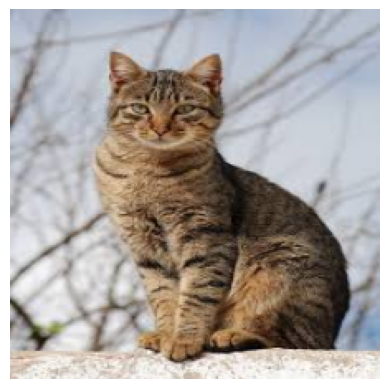

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("testmodel1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

img = img / 255.0
img = img.reshape(1, -1)

In [21]:
prediction = model.predict(img)
print("Prediction:", prediction)

Prediction: [0]


In [22]:
if prediction[0] == 0:
    print("Cat")
else:
    print("Dog")

Cat
